# 🚘 Data Analysis Project — Cars Dataset
**Dataset:** `CarsData.csv` — Car specifications and pricing (432 vehicles)  
**Goal:** Perform data cleaning, filtering, and transformation on real-world automotive data using Pandas  
**Tools:** Pandas · Matplotlib · Seaborn

> **Commands used in this project:**  
> `pd.read_csv` · `head()` · `shape` · `isnull().sum()` · `fillna()` · `value_counts()` · `isin()` · `apply()`


## 1. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [4]:
# Load the Cars dataset
car = pd.read_csv('CarsData.csv')

## 3. First Look at the Data

In [5]:
# First 5 rows — understand the structure and column types
car.head()

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265.0,17.0,23.0,4451.0,106.0,189.0
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200.0,24.0,31.0,2778.0,101.0,172.0
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200.0,22.0,29.0,3230.0,105.0,183.0
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270.0,20.0,28.0,3575.0,108.0,186.0
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225.0,18.0,24.0,3880.0,115.0,197.0


In [6]:
# Last 5 rows — confirm all data loaded correctly
car.tail()

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
427,Volvo,C70 LPT convertible 2dr,Sedan,Europe,Front,"$40,565","$38,203",2.4,5.0,197.0,21.0,28.0,3450.0,105.0,186.0
428,Volvo,C70 HPT convertible 2dr,Sedan,Europe,Front,"$42,565","$40,083",2.3,5.0,242.0,20.0,26.0,3450.0,105.0,186.0
429,Volvo,S80 T6 4dr,Sedan,Europe,Front,"$45,210","$42,573",2.9,6.0,268.0,19.0,26.0,3653.0,110.0,190.0
430,Volvo,V40,Wagon,Europe,Front,"$26,135","$24,641",1.9,4.0,170.0,22.0,29.0,2822.0,101.0,180.0
431,Volvo,XC70,Wagon,Europe,All,"$35,145","$33,112",2.5,5.0,208.0,20.0,27.0,3823.0,109.0,186.0


## 4. Data Structure & Info

In [7]:
# Number of rows and columns
print("Shape:", car.shape)

Shape: (432, 15)


In [8]:
# Data type of each column
car.dtypes

Make               str
Model              str
Type               str
Origin             str
DriveTrain         str
MSRP               str
Invoice            str
EngineSize     float64
Cylinders      float64
Horsepower     float64
MPG_City       float64
MPG_Highway    float64
Weight         float64
Wheelbase      float64
Length         float64
dtype: object

In [9]:
# Non-null counts and memory usage
car.info()

<class 'pandas.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         428 non-null    str    
 1   Model        428 non-null    str    
 2   Type         428 non-null    str    
 3   Origin       428 non-null    str    
 4   DriveTrain   428 non-null    str    
 5   MSRP         428 non-null    str    
 6   Invoice      428 non-null    str    
 7   EngineSize   428 non-null    float64
 8   Cylinders    426 non-null    float64
 9   Horsepower   428 non-null    float64
 10  MPG_City     428 non-null    float64
 11  MPG_Highway  428 non-null    float64
 12  Weight       428 non-null    float64
 13  Wheelbase    428 non-null    float64
 14  Length       428 non-null    float64
dtypes: float64(8), str(7)
memory usage: 50.8 KB


## 5. Descriptive Statistics

In [10]:
# Statistical summary of all numerical columns
car.describe().T

,count,mean,std,min,25%,50%,75%,max
EngineSize,428.0,3.196729,1.108595,1.3,2.375,3.0,3.90,8.3
Cylinders,426.0,5.807512,1.558443,3.0,4.000,6.0,6.00,12.0
Horsepower,428.0,215.885514,71.836032,73.0,165.000,210.0,255.00,500.0
MPG_City,428.0,20.060748,5.238218,10.0,17.000,19.0,21.25,60.0
MPG_Highway,428.0,26.843458,5.741201,12.0,24.000,26.0,29.00,66.0
Weight,428.0,3577.953271,758.983215,1850.0,3104.000,3474.5,3977.75,7190.0
Wheelbase,428.0,108.154206,8.311813,89.0,103.000,107.0,112.00,144.0
Length,428.0,186.362150,14.357991,143.0,178.000,187.0,194.00,238.0


## 6. Categorical Exploration

In [11]:
# Unique values for each categorical column
for col in ['Make', 'Type', 'Origin', 'DriveTrain']:
    print(f"{col}: {car[col].nunique()} unique values → {car[col].unique().tolist()}")
    print()

Make: 38 unique values → ['Acura', 'Audi', 'BMW', nan, 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'Ford', 'GMC', 'Honda', 'Hummer', 'Hyundai', 'Infiniti', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'Lincoln', 'MINI', 'Mazda', 'Mercedes-Benz', 'Mercury', 'Mitsubishi', 'Nissan', 'Oldsmobile', 'Pontiac', 'Porsche', 'Saab', 'Saturn', 'Scion', 'Subaru', 'Suzuki', 'Toyota', 'Volkswagen', 'Volvo']

Type: 6 unique values → ['SUV', 'Sedan', 'Sports', 'Wagon', nan, 'Truck', 'Hybrid']

Origin: 3 unique values → ['Asia', 'Europe', nan, 'USA']

DriveTrain: 3 unique values → ['All', 'Front', 'Rear', nan]



---
## 📋 Analytical Questions
---

### Q1 — Data Cleaning: Fill Null Values with Column Mean

> **Task:** Find all null values in the dataset. If any column has missing values, fill them with the mean of that column.

> ⚠️ **Note:** `fillna()` with mean only works on **numerical columns** — categorical columns (Make, Model, Type, Origin, DriveTrain) need a different strategy such as filling with the mode or dropping the rows.


In [12]:
# Step 1: Check missing values in each column before cleaning
print("Missing values before cleaning:")
print(car.isnull().sum())
print()

# Step 2: Separate numerical and categorical columns
num_cols = car.select_dtypes(include='number').columns
cat_cols = car.select_dtypes(exclude='number').columns

print("Numerical columns:", num_cols.tolist())
print("Categorical columns:", cat_cols.tolist())

Missing values before cleaning:
Make           4
Model          4
Type           4
Origin         4
DriveTrain     4
MSRP           4
Invoice        4
EngineSize     4
Cylinders      6
Horsepower     4
MPG_City       4
MPG_Highway    4
Weight         4
Wheelbase      4
Length         4
dtype: int64

Numerical columns: ['EngineSize', 'Cylinders', 'Horsepower', 'MPG_City', 'MPG_Highway', 'Weight', 'Wheelbase', 'Length']
Categorical columns: ['Make', 'Model', 'Type', 'Origin', 'DriveTrain', 'MSRP', 'Invoice']


In [13]:
# Step 3: Fill missing values in numerical columns with their mean
for col in num_cols:
    car[col].fillna(car[col].mean(), inplace=True)

# Step 4: Fill missing values in categorical columns with their mode
for col in cat_cols:
    car[col].fillna(car[col].mode()[0], inplace=True)

# Step 5: Confirm no missing values remain
print("Missing values after cleaning:")
print(car.isnull().sum())

Missing values after cleaning:
Make           4
Model          4
Type           4
Origin         4
DriveTrain     4
MSRP           4
Invoice        4
EngineSize     4
Cylinders      6
Horsepower     4
MPG_City       4
MPG_Highway    4
Weight         4
Wheelbase      4
Length         4
dtype: int64


### Q2 — Value Counts: Different Types of Car Makes

> **Task:** Check what different types of Make are in the dataset and what is the count (occurrence) of each Make.


In [14]:
# Count of each car Make — sorted by frequency
print(car['Make'].value_counts())
print()
print(f"Total unique Makes: {car['Make'].nunique()}")

Make
Toyota           28
Chevrolet        27
Mercedes-Benz    26
Ford             23
BMW              20
Audi             19
Honda            17
Nissan           17
Chrysler         15
Volkswagen       15
Dodge            13
Mitsubishi       13
Hyundai          12
Jaguar           12
Volvo            12
Kia              11
Lexus            11
Mazda            11
Pontiac          11
Subaru           11
Buick             9
Lincoln           9
Mercury           9
Cadillac          8
GMC               8
Infiniti          8
Saturn            8
Suzuki            8
Acura             7
Porsche           7
Saab              7
Jeep              3
Land Rover        3
Oldsmobile        3
Isuzu             2
MINI              2
Scion             2
Hummer            1
Name: count, dtype: int64

Total unique Makes: 38


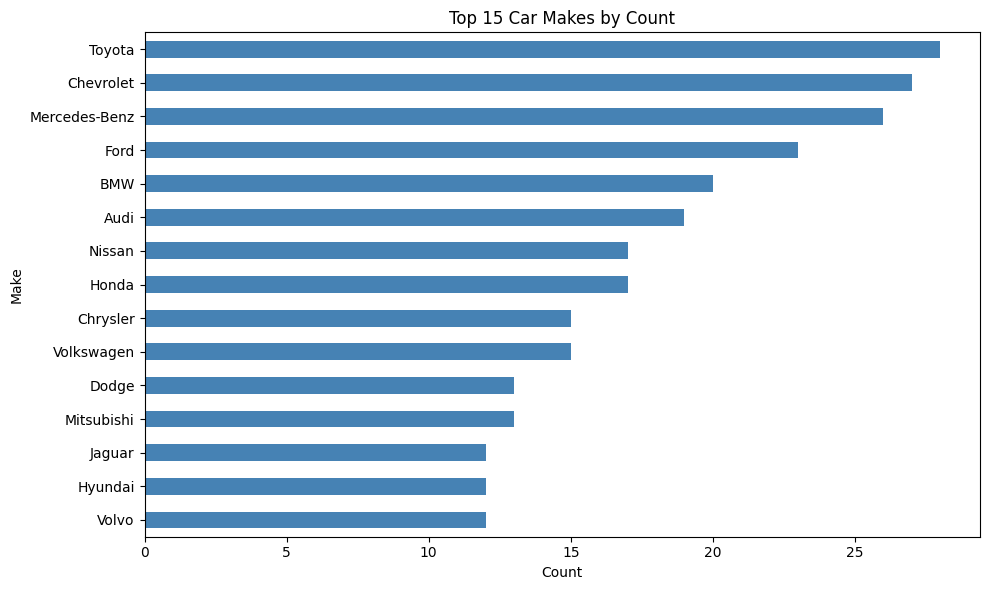

In [15]:
# Visualize Top 15 Makes for better readability
top15_makes = car['Make'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top15_makes.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 15 Car Makes by Count")
plt.xlabel("Count")
plt.ylabel("Make")
plt.tight_layout()
plt.show()

### Q3 — Filtering: Show all records where Origin is Asia or Europe

> **Task:** Use `isin()` to filter records where the car's origin is either Asia or Europe.


In [16]:
# isin() checks if a value belongs to a given list — returns a boolean mask
asia_europe = car[car['Origin'].isin(['Asia', 'Europe'])]

print(f"Total records from Asia or Europe: {len(asia_europe)}")
asia_europe.head(10)

Total records from Asia or Europe: 281


,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265.0,17.0,23.0,4451.0,106.0,189.0
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200.0,24.0,31.0,2778.0,101.0,172.0
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200.0,22.0,29.0,3230.0,105.0,183.0
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270.0,20.0,28.0,3575.0,108.0,186.0
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225.0,18.0,24.0,3880.0,115.0,197.0
5,Acura,3.5 RL w/Navigation 4dr,Sedan,Asia,Front,"$46,100","$41,100",3.5,6.0,225.0,18.0,24.0,3893.0,115.0,197.0
6,Acura,NSX coupe 2dr manual S,Sports,Asia,Rear,"$89,765","$79,978",3.2,6.0,290.0,17.0,24.0,3153.0,100.0,174.0
7,Audi,A4 1.8T 4dr,Sedan,Europe,Front,"$25,940","$23,508",1.8,4.0,170.0,22.0,31.0,3252.0,104.0,179.0
8,Audi,A41.8T convertible 2dr,Sedan,Europe,Front,"$35,940","$32,506",1.8,4.0,170.0,23.0,30.0,3638.0,105.0,180.0
9,Audi,A4 3.0 4dr,Sedan,Europe,Front,"$31,840","$28,846",3.0,6.0,220.0,20.0,28.0,3462.0,104.0,179.0


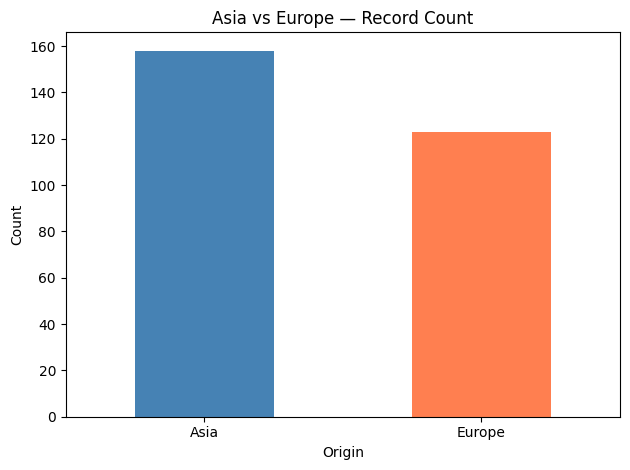

In [17]:
# Distribution of Asia vs Europe in the filtered data
asia_europe['Origin'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title("Asia vs Europe — Record Count")
plt.xlabel("Origin")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q4 — Removing Unwanted Records: Drop rows where Weight > 4000

> **Task:** Remove all rows where the car's Weight exceeds 4000.

> ⚠️ **Two approaches:**  
> - `car[car['Weight'] <= 4000]` — keep rows where weight is 4000 or below (equivalent to removing > 4000)  
> - `car[~(car['Weight'] > 4000)]` — use `~` (NOT operator) to invert the condition  
> Both produce identical results. The first approach is more readable.


In [18]:
# Check how many records have Weight > 4000 before removing
print(f"Records with Weight > 4000: {len(car[car['Weight'] > 4000])}")
print(f"Total records before removal: {len(car)}")

Records with Weight > 4000: 103
Total records before removal: 432


In [19]:
# Remove all rows where Weight > 4000
# Using ~ (NOT) operator to invert the condition
car = car[~(car['Weight'] > 4000)]

print(f"Total records after removal: {len(car)}")

Total records after removal: 329


### Q5 — Applying a Function: Increase all MPG_City values by 3

> **Task:** Use `apply()` with a lambda function to increase all values in the `MPG_City` column by 3.

> 💡 **Why apply() and not just `+3` directly?**  
> Both `car['MPG_City'] + 3` and `car['MPG_City'].apply(lambda x: x + 3)` give the same result here.  
> However, `apply()` is more powerful — it can handle complex custom functions, conditional logic, and multi-column operations that simple arithmetic can't do.


In [20]:
# Check MPG_City values before applying the function
print("MPG_City before:")
print(car['MPG_City'].describe())

MPG_City before:
count    325.000000
mean      21.452308
std        5.180838
min       12.000000
25%       18.000000
50%       20.000000
75%       24.000000
max       60.000000
Name: MPG_City, dtype: float64


In [21]:
# Apply lambda function to increase each MPG_City value by 3
car['MPG_City'] = car['MPG_City'].apply(lambda x: x + 3)

print("MPG_City after (+3):")
print(car['MPG_City'].describe())

MPG_City after (+3):
count    325.000000
mean      24.452308
std        5.180838
min       15.000000
25%       21.000000
50%       23.000000
75%       27.000000
max       63.000000
Name: MPG_City, dtype: float64


In [22]:
# Confirm the change visually — first 5 rows
car[['Make', 'Model', 'MPG_City', 'MPG_Highway']].head()

,Make,Model,MPG_City,MPG_Highway
1,Acura,RSX Type S 2dr,27.0,31.0
2,Acura,TSX 4dr,25.0,29.0
3,Acura,TL 4dr,23.0,28.0
4,Acura,3.5 RL 4dr,21.0,24.0
5,Acura,3.5 RL w/Navigation 4dr,21.0,24.0


## 7. Visualizations

### 7.1 Univariate — Numerical Variables

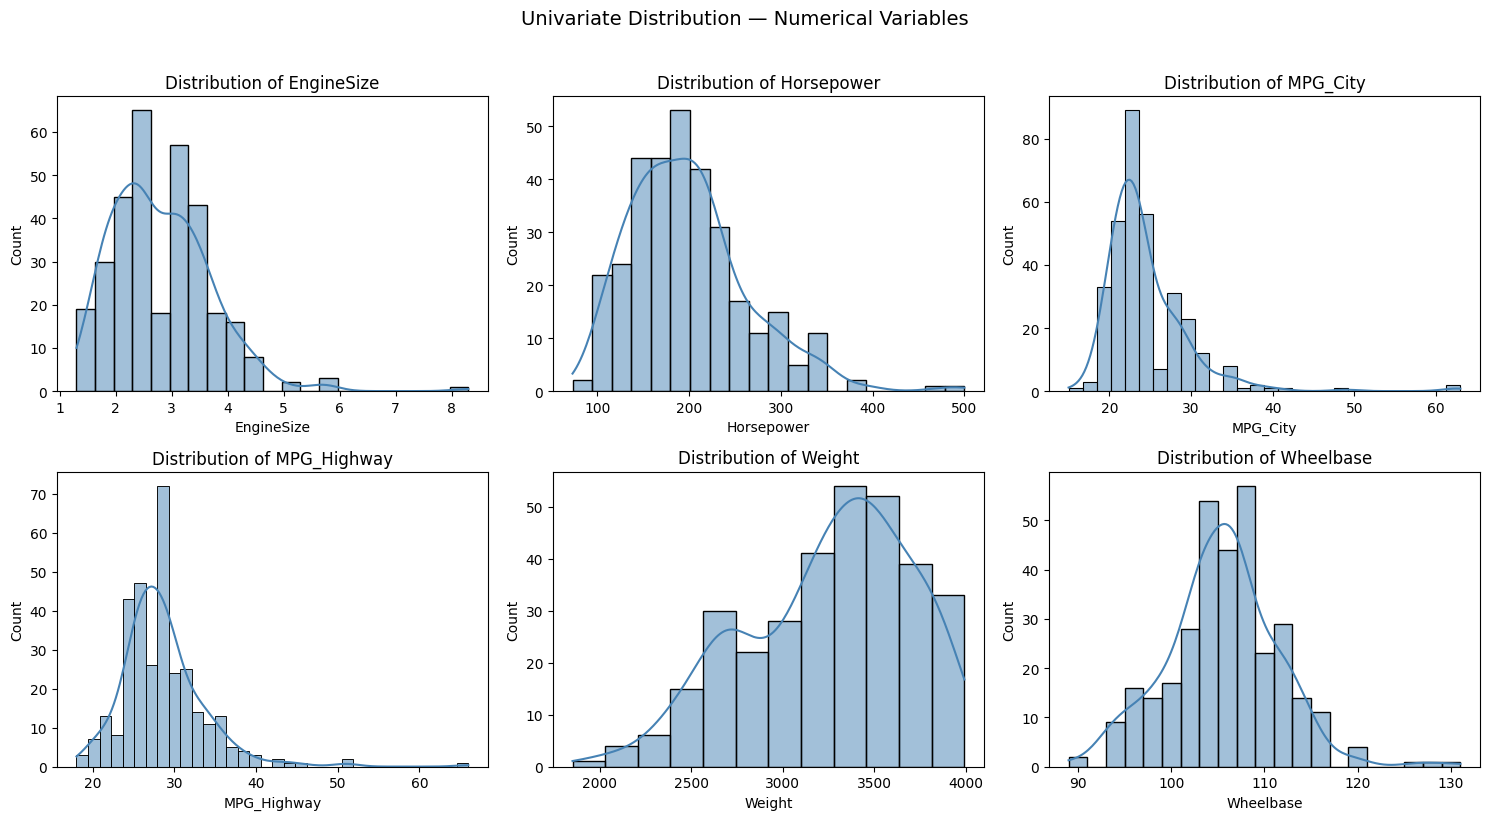

In [23]:
# Distribution of all key numerical columns
num_cols = ['EngineSize', 'Horsepower', 'MPG_City', 'MPG_Highway', 'Weight', 'Wheelbase']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(car[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle("Univariate Distribution — Numerical Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

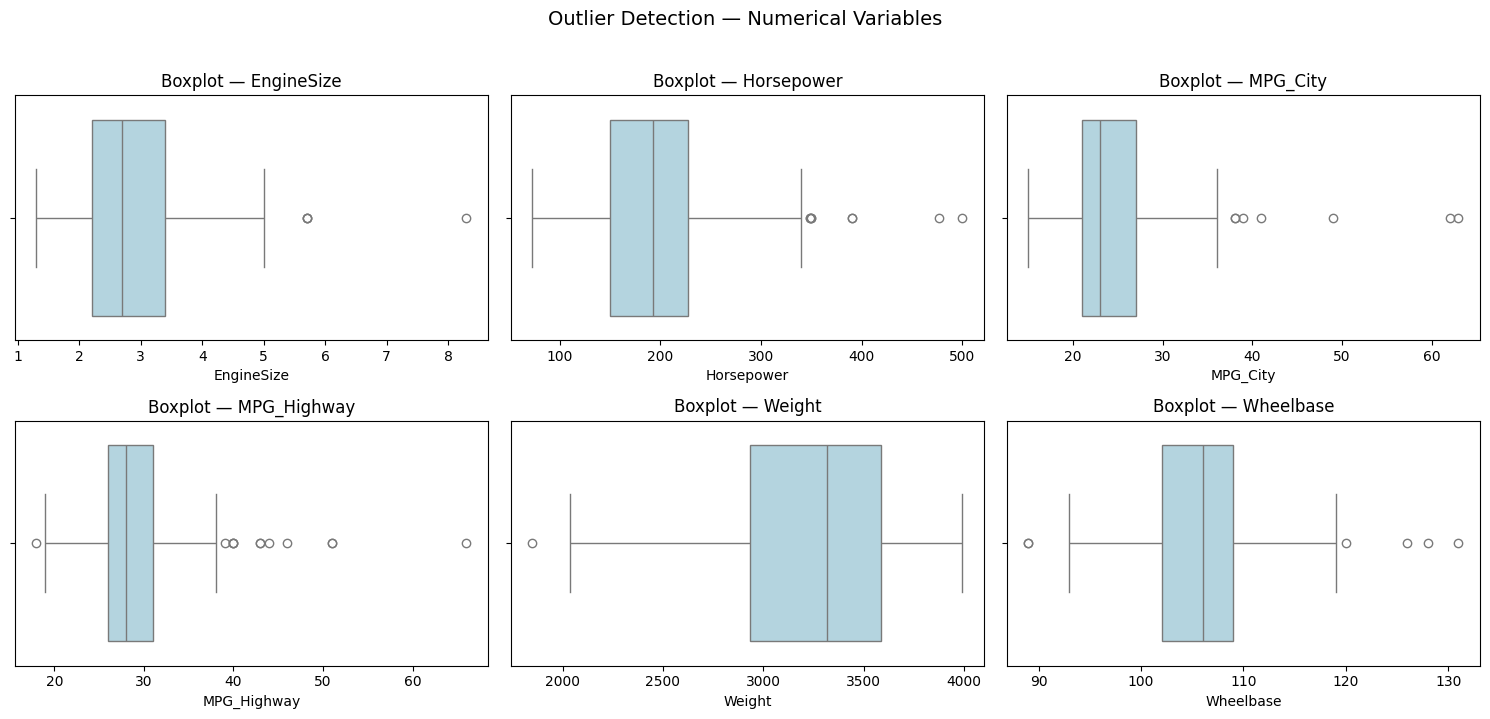

In [24]:
# Boxplot for outlier detection across all numerical columns
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=car[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot — {col}')

plt.suptitle("Outlier Detection — Numerical Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Univariate — Categorical Variables

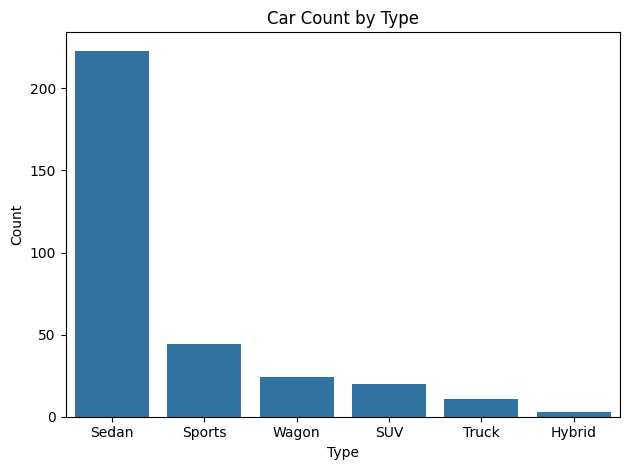

In [25]:
# Count per car Type
sns.countplot(x='Type', data=car, order=car['Type'].value_counts().index)
plt.title("Car Count by Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

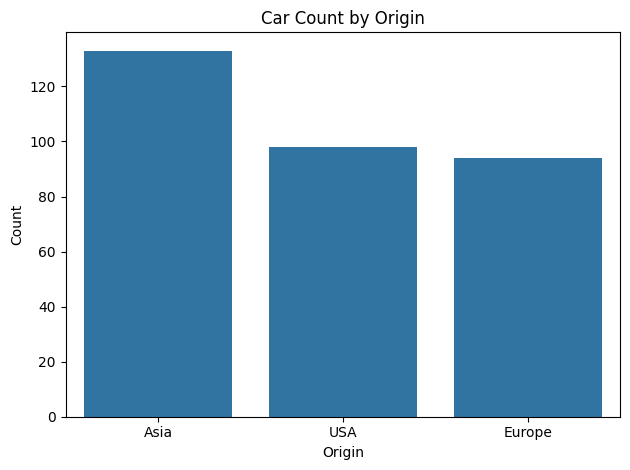

In [26]:
# Count per Origin
sns.countplot(x='Origin', data=car, order=car['Origin'].value_counts().index)
plt.title("Car Count by Origin")
plt.xlabel("Origin")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

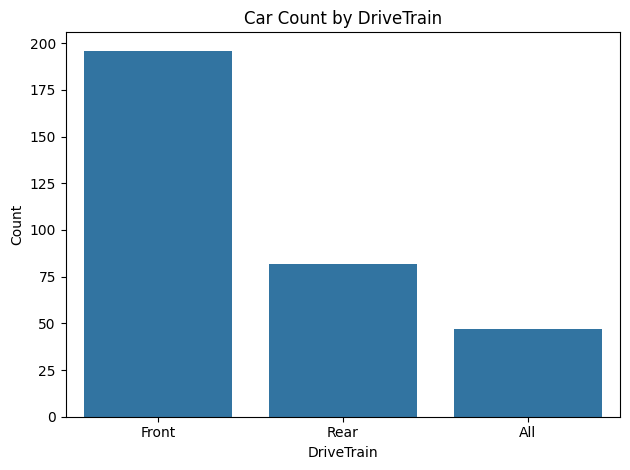

In [27]:
# Count per DriveTrain
sns.countplot(x='DriveTrain', data=car, order=car['DriveTrain'].value_counts().index)
plt.title("Car Count by DriveTrain")
plt.xlabel("DriveTrain")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 7.3 Bivariate — Numerical vs Numerical

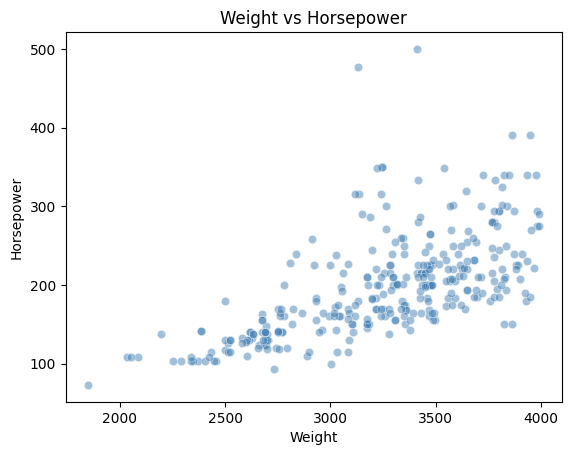

In [28]:
# Horsepower vs Weight — heavier cars tend to have more power?
sns.scatterplot(x='Weight', y='Horsepower', data=car, alpha=0.5, color='steelblue')
plt.title("Weight vs Horsepower")
plt.show()

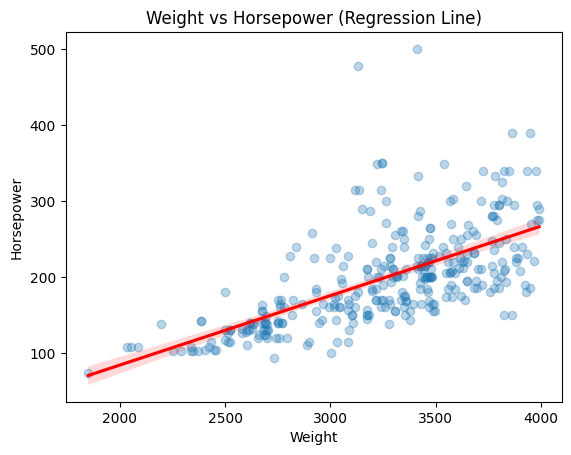

In [29]:
# Regression line to quantify the relationship
sns.regplot(x='Weight', y='Horsepower', data=car,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title("Weight vs Horsepower (Regression Line)")
plt.show()

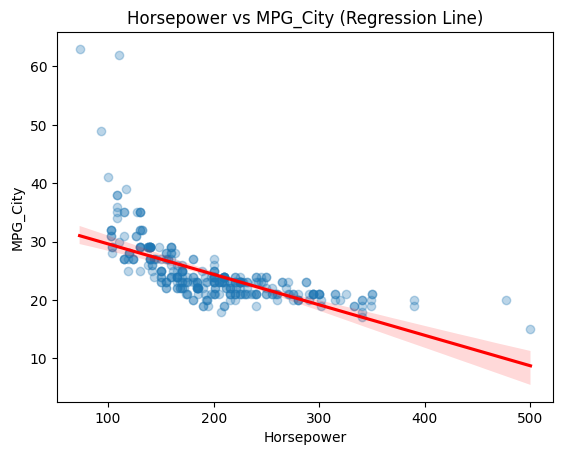

In [30]:
# MPG_City vs Horsepower — more power = less fuel efficiency?
sns.regplot(x='Horsepower', y='MPG_City', data=car,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title("Horsepower vs MPG_City (Regression Line)")
plt.show()

### 7.4 Bivariate — Numerical vs Categorical

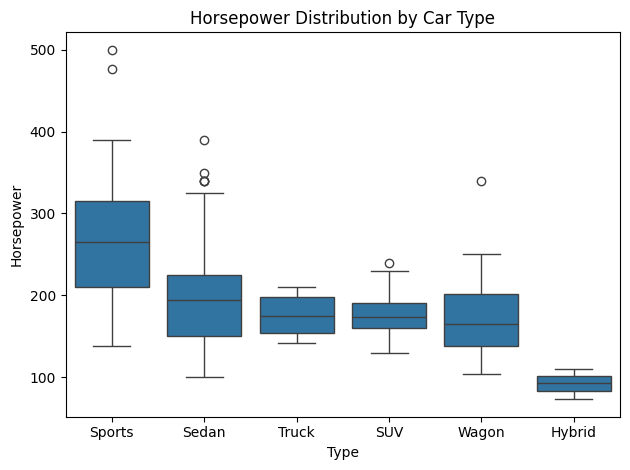

In [31]:
# Horsepower distribution per car Type
sns.boxplot(x='Type', y='Horsepower', data=car,
            order=car.groupby('Type')['Horsepower'].median().sort_values(ascending=False).index)
plt.title("Horsepower Distribution by Car Type")
plt.tight_layout()
plt.show()

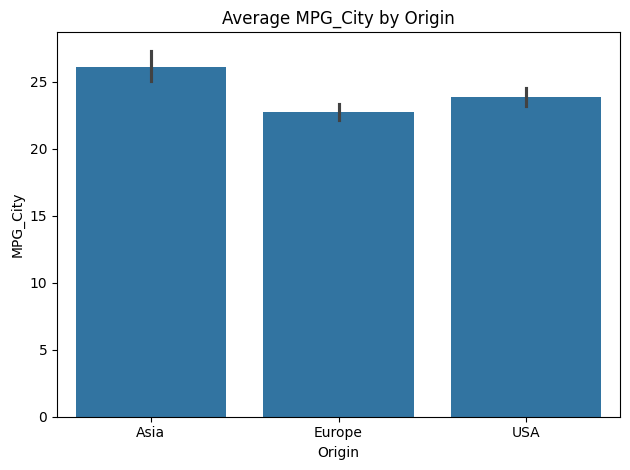

In [32]:
# Average MPG_City per Origin — which origin is most fuel efficient?
sns.barplot(x='Origin', y='MPG_City', data=car)
plt.title("Average MPG_City by Origin")
plt.tight_layout()
plt.show()

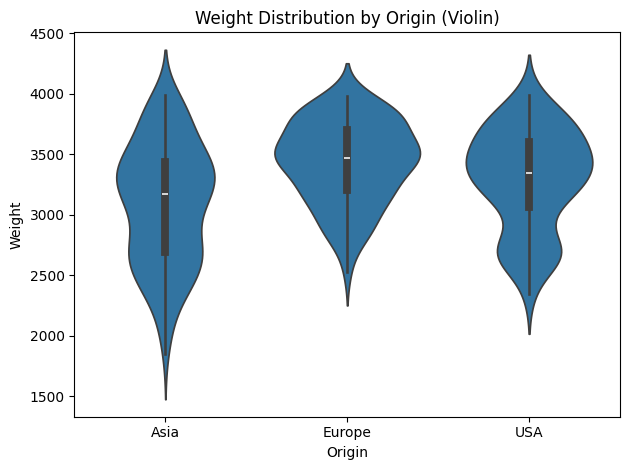

In [33]:
# Weight distribution per Origin
sns.violinplot(x='Origin', y='Weight', data=car)
plt.title("Weight Distribution by Origin (Violin)")
plt.tight_layout()
plt.show()

### 7.5 Bivariate — Categorical vs Categorical

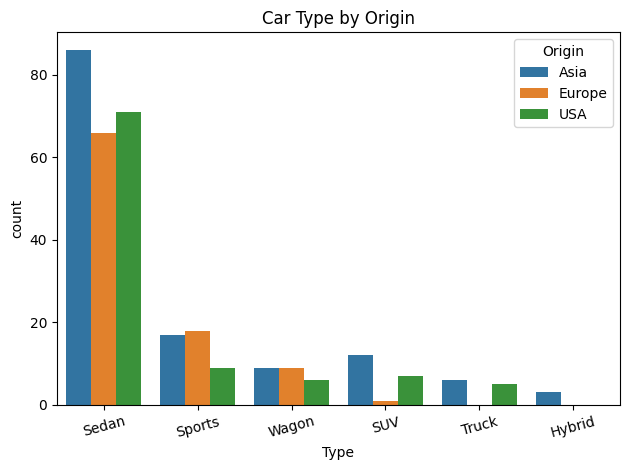

In [34]:
# Car Type distribution per Origin — which origin makes which types?
sns.countplot(x='Type', hue='Origin', data=car,
              order=car['Type'].value_counts().index)
plt.title("Car Type by Origin")
plt.xticks(rotation=15)
plt.legend(title='Origin')
plt.tight_layout()
plt.show()

### 7.6 Multivariate Analysis

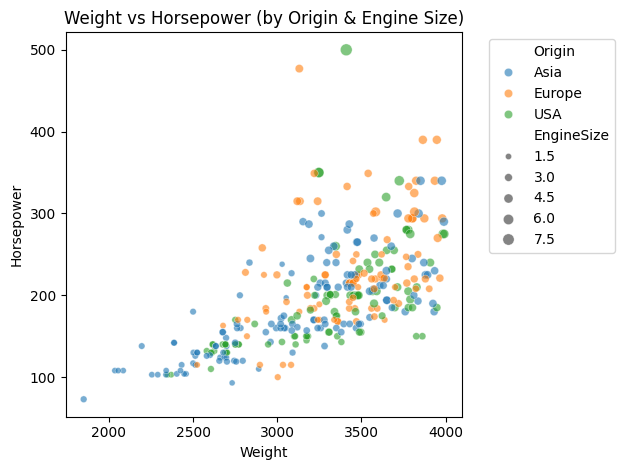

In [35]:
# Weight vs Horsepower — colored by Origin, sized by EngineSize
sns.scatterplot(
    x='Weight', y='Horsepower',
    hue='Origin', size='EngineSize',
    data=car, alpha=0.6
)
plt.title("Weight vs Horsepower (by Origin & Engine Size)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

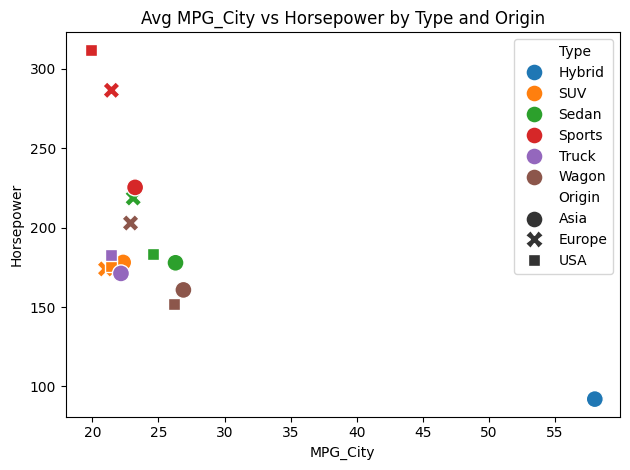

In [36]:
# Average MPG_City and Horsepower per Type and Origin
group_means = car.groupby(['Type', 'Origin'])[['MPG_City', 'Horsepower']].mean().reset_index()

sns.scatterplot(x='MPG_City', y='Horsepower', hue='Type', style='Origin', data=group_means, s=150)
plt.title("Avg MPG_City vs Horsepower by Type and Origin")
plt.tight_layout()
plt.show()

### 7.7 Correlation Heatmap

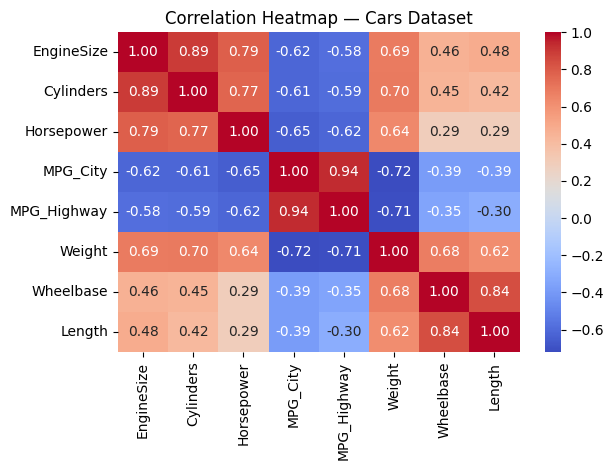

In [37]:
# Heatmap of correlations between all numerical variables
sns.heatmap(car.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap — Cars Dataset")
plt.tight_layout()
plt.show()

### 7.8 Pairplot

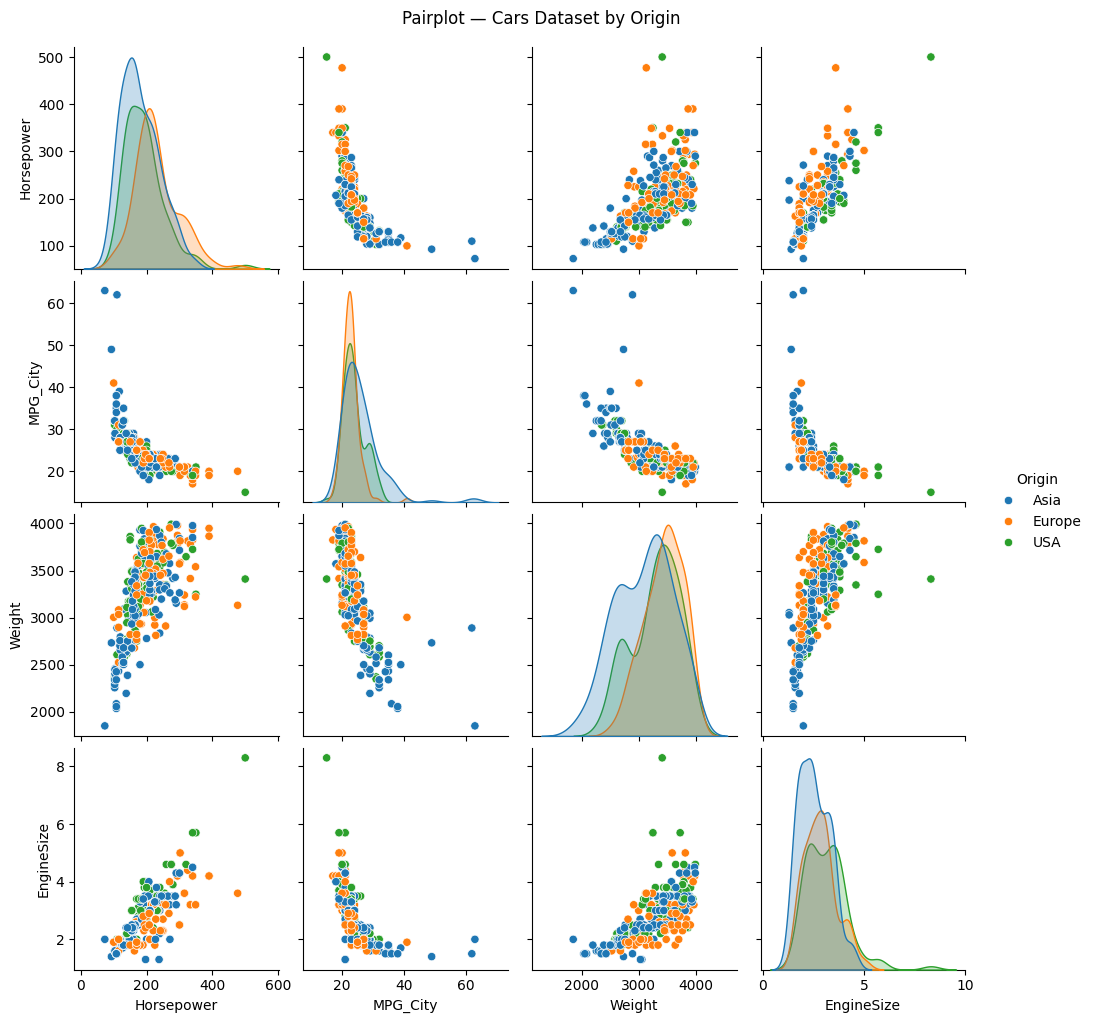

In [38]:
# Pairplot colored by Origin — quick overview of all relationships
sns.pairplot(
    car[['Horsepower', 'MPG_City', 'Weight', 'EngineSize', 'Origin']],
    hue='Origin'
)
plt.suptitle("Pairplot — Cars Dataset by Origin", y=1.02)
plt.show()

## 8. Key Insights

After analyzing **432 car records** across 15 features:

1. **Heavier cars have significantly more horsepower**  
   There is a strong positive correlation between Weight and Horsepower — confirmed by both the scatter plot and the correlation heatmap.

2. **More horsepower = lower fuel efficiency**  
   MPG_City has a clear negative correlation with Horsepower and EngineSize — high-performance cars consume more fuel in city driving.

3. **Asian cars are the most fuel-efficient**  
   The barplot of MPG_City by Origin shows Asian cars lead in city fuel efficiency, followed by European cars, with USA cars trailing behind.

4. **Sports cars dominate in horsepower, Trucks in weight**  
   The boxplot of Horsepower by Type reveals Sports cars have the highest median horsepower, while Trucks are the heaviest category.

5. **USA dominates SUV and Truck segments**  
   The categorical countplot shows that most SUVs and Trucks in the dataset originate from the USA, while Asia leads in Sedans.

6. **Over 20% of records had Weight > 4000**  
   Before filtering, a substantial portion of records exceeded the 4000 weight threshold — mostly Trucks and large SUVs from USA manufacturers.
